# Differece calculations between frames

In [4]:
import numpy as np 
import pandas as pd 
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt 
import cv2

## Load in the data

In [5]:
def get_data(dataset,X,num=-1,augment=False,sobel=True,printer="resin",filament="resin",pressure="P30",pattern="",augtests=[]):
    subset = dataset[((dataset['Printer'] == printer) & (dataset['Filament']==filament)) ]
    if pattern!="":
        subset = subset[subset['Pattern'].str.contains(pattern, regex=False, na=False) ]
    subX, y = [], []
    for _, row in subset.iterrows():
        images=X[int(row['Index'])]
        images=images.reshape((2*25,images.shape[2],images.shape[3]))
        try:
            label=int(row['Pattern'].split(".")[0].replace("z", ""))
        except:
            label=""
        if label!="":
            for image in images:
                if sobel:
                    # Apply Sobel filter (on grayscale if not already)
                    if len(image.shape) == 3:  # convert to grayscale if it's RGB
                        roi_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                    else:
                        roi_gray = image

                    sobelx = cv2.Sobel(roi_gray, cv2.CV_64F, 1, 0, ksize=3)
                    sobely = cv2.Sobel(roi_gray, cv2.CV_64F, 0, 1, ksize=3)

                    sobel_ = np.hypot(sobelx, sobely)  # magnitude
                    image = cv2.convertScaleAbs(sobel_)  # scale back to uint8
                if num==-1:
                    y.append(label)
                    subX.append(image)
                else: 
                    try:
                        counter=int(row['Pattern'].split(".")[1])
                        if counter==num:
                            y.append(label)
                            subX.append(image)
                    except:
                        pass
    subX,y=np.array(subX),np.array(y)
    if augment:
        if len(augtests)==0 or 0 in augtests:
            noisy=subX+np.random.normal(0,5,subX.shape)
            subX=np.concatenate([subX,noisy])
            y=np.concatenate([y,y])
        if len(augtests)==1 or 1 in augtests:
            light=subX.copy()-10
            dark=subX.copy()+10
            light[light<0]=0
            dark[dark>255]=255
            subX=np.concatenate([subX,light,dark])
            y=np.concatenate([y,y,y])
    assert len(subX)==len(y) 
    return subX.reshape((len(subX)//(2*25),2,25,subX.shape[1],subX.shape[2])),y #shape into correct format

def coral_align_target_to_source(Xs, Xt, eps=1e-6):
    # center
    mu_s = Xs.mean(axis=0, keepdims=True)
    mu_t = Xt.mean(axis=0, keepdims=True)
    Xs_c = Xs - mu_s
    Xt_c = Xt - mu_t

    # covariances with small ridge
    cov_s = np.cov(Xs_c, rowvar=False) + np.eye(Xs_c.shape[1]) * eps
    cov_t = np.cov(Xt_c, rowvar=False) + np.eye(Xt_c.shape[1]) * eps

    # matrix square-roots via SVD
    Us, Ss, _ = np.linalg.svd(cov_s)
    Ut, St, _ = np.linalg.svd(cov_t)
    # cov_s^{1/2} and cov_t^{-1/2}
    cov_s_sqrt = Us @ np.diag(np.sqrt(Ss)) @ Us.T
    cov_t_inv_sqrt = Ut @ np.diag(1.0/np.sqrt(St)) @ Ut.T

    # transform target: Xt_aligned = (Xt_c @ cov_t^{-1/2}) @ cov_s^{1/2} + mu_s
    Xt_aligned = (Xt_c @ cov_t_inv_sqrt) @ cov_s_sqrt + mu_s
    return Xt_aligned

X=np.load("/home/dexter/Documents/GitHub/3D-textures/Experimental/data/X.npy")
dataset=pd.read_csv("/home/dexter/Documents/GitHub/3D-textures/Experimental/datameta.csv")
print("Original X shape:", X.shape)
print("Original dataset size:", len(dataset))
printers=[["resin","resin"],["ender","PLAplus"],["bambu","PLAminus"],]

image_brightness = X.mean(axis=(3, 4))
# shape: N x 2 x 25

# Overall distribution of image brightness
mean_brightness = image_brightness.mean()
std_brightness = image_brightness.std()

threshold = mean_brightness - 3 * std_brightness

print(f"Mean brightness: {mean_brightness:.2f}")
print(f"Std brightness:  {std_brightness:.2f}")
print(f"Darkness threshold: {threshold:.2f}")
dark_images = image_brightness < threshold

# An N sample is rejected if ANY of its 2 x 25 images
# is unusually dark
reject = dark_images.any(axis=(1, 2))

print(f"Rejected samples: {reject.sum()} / {len(reject)}")

X = X[~reject]
print(dataset[reject])
dataset = dataset.iloc[np.where(~reject)[0]].reset_index(drop=True)
dataset["Index"] = np.arange(len(dataset))
print("Clean X shape:", X.shape)
print("Clean dataset size:", len(dataset))


Original X shape: (204, 2, 25, 192, 256)
Original dataset size: 204
Mean brightness: 142.69
Std brightness:  8.65
Darkness threshold: 116.75
Rejected samples: 4 / 204
     Unnamed: 0  Index  Filament Pattern Printer Pressure
91           91   91.0   PLAplus    z5.1   ender      P30
95           95   95.0     resin    z0.1   resin      P30
120         120  120.0   PLAplus      z0   Ender      P30
157         157  157.0  PLAminus    flat   bambu      P30
Clean X shape: (200, 2, 25, 192, 256)
Clean dataset size: 200


In [6]:
dataset.head()

,Unnamed: 0,Index,Filament,Pattern,Printer,Pressure
0,0,0,PLAminus,z1.2,bambu,P30
1,1,1,PLAminus,z4.1,bambu,P30
2,2,2,wood,z0,bambu,P30
3,3,3,wood,z3,bambu,P30
4,4,4,resin,z5.5,resin,P30


In [7]:
background="/home/dexter/Videos/WIN_20260814_11_07_49_Pro.mp4"
cap = cv2.VideoCapture(background)

msrs = []
frames = []

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)

cap.release()

frames = np.asarray(frames, dtype=np.float32)

# Compare consecutive frames
diff = (frames[:-1] - frames[1:]) ** 2

# MSR for each pair of frames
frame_msrs = np.mean(diff.mean(axis=(1, 2, 3)))
frame_msrs,len(frames)

(np.float32(3.6787784), 136)

## calculate

In [ ]:
overall_means=[]

for j in range(len(printers)):
    comb = printers[j]
    print("###################################")
    
    for i in range(0, 6):
        X_c, y_c = get_data(
            dataset, X,
            printer=comb[0],
            filament=comb[1],
            pattern="z"+str(i),
            pressure="P30"
        )
        #print(X_c.shape, comb[0],comb[1],"z"+str(i))
        #n = len(X_c)*2*25
        ar=[]
        methods=[]
        for j in range(len(X_c)):
            for k in range(j,len(X_c)):
                if k!=j:
                        # shape (2, 25, h, w )
                        diff = (X_c[k,] - X_c[j,]) ** 2
                        msr_per_point = np.mean(diff, axis=( 2, 3))
                        #print(msr_per_point.shape)
                        # (25)
                        ar.append(msr_per_point)
                        #print(j,k,np.array(ar).shape)
            #n = len(ar)*2*25
            diff = (X_c[j, 0] - X_c[j, 1]) ** 2
            method_error_per_point = np.mean(diff, axis=(1, 2))
            #print(method_error_per_point.shape)
            methods.append(method_error_per_point)
        #print(np.array(ar).shape)
        msr_n= len(ar)*25*2
        method_n= len(methods)*25*2
        msr_mean = np.mean(np.array(ar))
        msr_std = np.std(np.array(ar))
        method_error = np.mean(np.array(methods))
        method_STD = np.std(np.array(methods))
        """print(
            "Texture:", i,
            ", Printer:", comb[0],
            f"MSR: {msr_mean:.2f} ± {msr_std:.2f}",
            f"Method error {methods:.2f}",
            f"Corrected {msr_mean-methods:.2f}",
        )"""
        overall_means.append({
            "Texture": i,
            "Printer": comb[0],
            "Filament": comb[1],
            "N": msr_n,
            "method_n":method_n,
            "MSR Mean": msr_mean,
            "MSR Std": msr_std,
            "Method Error": method_error,
            "Method STD": method_STD,
            "Corrected": msr_mean - method_error
        })
overall_means_df = pd.DataFrame(overall_means)
overall_means_df.to_csv("/home/dexter/Documents/GitHub/3D-textures/assets/overall_means_images.csv", index=False)
overall_means_df


###################################
###################################


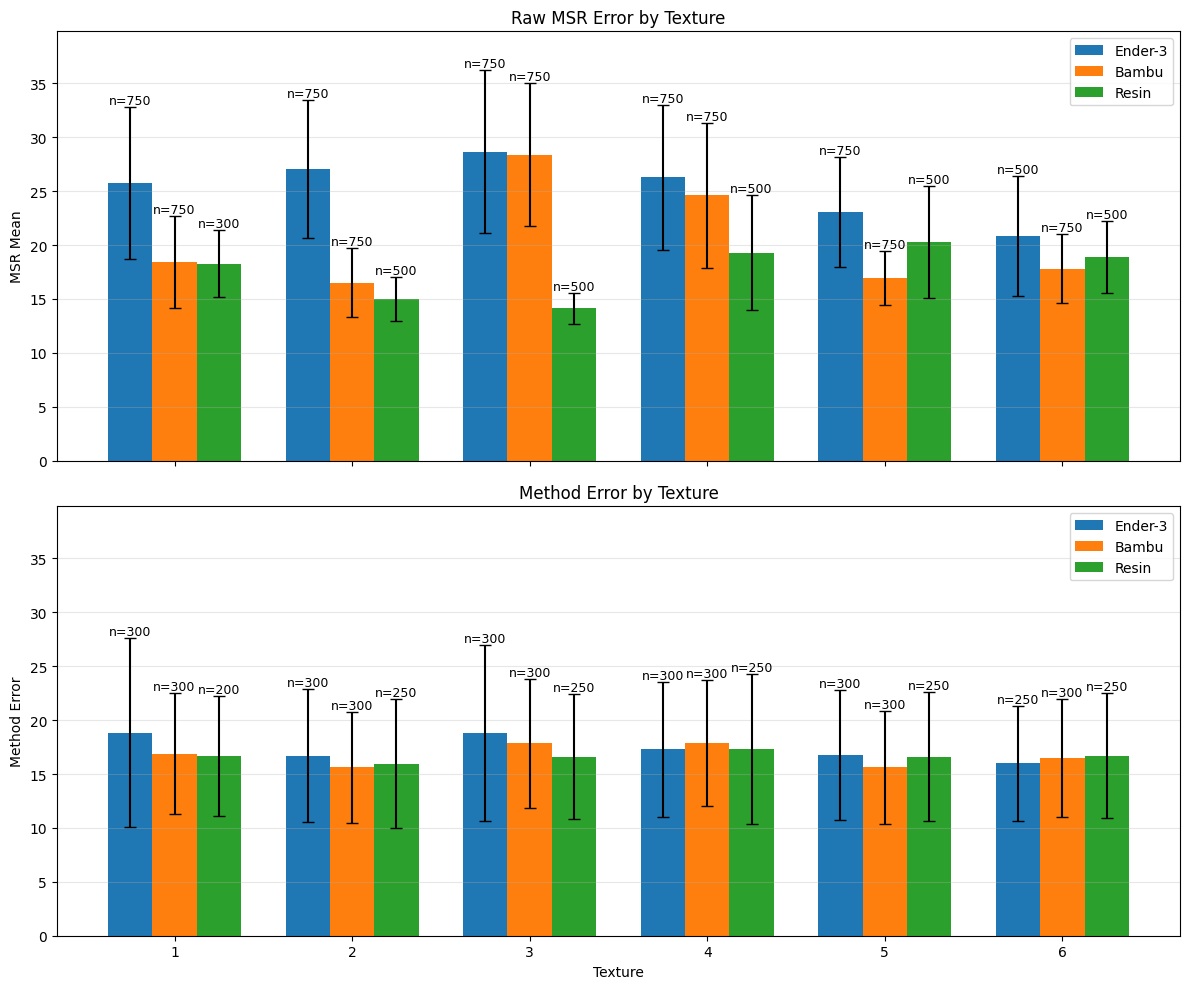

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Actual texture values in overall_means: 0–5
textures = sorted(set(row["Texture"] for row in overall_means))

# Display labels: 1–6
texture_labels = [t + 1 for t in textures]

# Bar order: Ender-3 → Bambu → Resin
combinations = [
    ["ender", "PLAplus"],
    ["bambu", "PLAminus"],
    ["resin", "resin"],
]

# Display names
printer_labels = {
    "ender": "Ender-3",
    "bambu": "Bambu",
    "resin": "Resin"
}

x = np.arange(len(textures))
width = 0.25


# ---------------------------------------------------------
# Find common Y-axis maximum
# ---------------------------------------------------------

all_values = []

for printer, filament in combinations:

    rows = [
        row for row in overall_means
        if row["Printer"] == printer
        and row["Filament"] == filament
    ]

    # MSR Mean + MSR STD
    for texture in textures:
        row = next(row for row in rows if row["Texture"] == texture)
        all_values.append(row["MSR Mean"] + row["MSR Std"])

    # Method Error + Method STD
    for texture in textures:
        row = next(row for row in rows if row["Texture"] == texture)
        all_values.append(row["Method Error"] + row["Method STD"])


# Add 10% headroom
y_max = max(all_values) * 1.1


# ---------------------------------------------------------
# Create charts
# ---------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)


# ---------------------------------------------------------
# CHART 1: Raw MSR Mean + MSR Std
# ---------------------------------------------------------

ax = axes[0]

for j, (printer, filament) in enumerate(combinations):

    rows = [
        row for row in overall_means
        if row["Printer"] == printer
        and row["Filament"] == filament
    ]

    means = [
        next(row["MSR Mean"] for row in rows if row["Texture"] == texture)
        for texture in textures
    ]

    stds = [
        next(row["MSR Std"] for row in rows if row["Texture"] == texture)
        for texture in textures
    ]

    bars = ax.bar(
        x + (j - 1) * width,
        means,
        width,
        yerr=stds,
        capsize=4,
        label=printer_labels[printer]
    )

    # Add sample count above each bar
    for bar, texture in zip(bars, textures):
        row = next(row for row in rows if row["Texture"] == texture)
        n = row["N"]

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + stds[textures.index(texture)],
            f"n={n}",
            ha="center",
            va="bottom",
            fontsize=9
        )


ax.set_title("Raw MSR Error by Texture")
ax.set_ylabel("MSR Mean")
ax.set_ylim(0, y_max)
ax.set_xticks(x)
ax.set_xticklabels(texture_labels)
ax.legend()
ax.grid(axis="y", alpha=0.3)


# ---------------------------------------------------------
# CHART 2: Method Error + Method STD
# ---------------------------------------------------------

ax = axes[1]

for j, (printer, filament) in enumerate(combinations):

    rows = [
        row for row in overall_means
        if row["Printer"] == printer
        and row["Filament"] == filament
    ]

    errors = [
        next(row["Method Error"] for row in rows if row["Texture"] == texture)
        for texture in textures
    ]

    stds = [
        next(row["Method STD"] for row in rows if row["Texture"] == texture)
        for texture in textures
    ]

    bars = ax.bar(
        x + (j - 1) * width,
        errors,
        width,
        yerr=stds,
        capsize=4,
        label=printer_labels[printer]
    )

    # Add sample count above each bar
    for bar, texture, std in zip(bars, textures, stds):
        row = next(row for row in rows if row["Texture"] == texture)
        n = row["method_n"]

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std,
            f"n={n}",
            ha="center",
            va="bottom",
            fontsize=9
        )


ax.set_title("Method Error by Texture")
ax.set_xlabel("Texture")
ax.set_ylabel("Method Error")
ax.set_ylim(0, y_max)
ax.set_xticks(x)
ax.set_xticklabels(texture_labels)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/home/dexter/Documents/GitHub/3D-textures/assets/msr_3dprint.pdf")
plt.show()

In [ ]:
from scipy.stats import ttest_ind

for printer in overall_means_df["Printer"].unique():

    for texture in overall_means_df["Texture"].unique():

        msr = overall_means_df[
            (overall_means_df["Printer"] == printer) &
            (overall_means_df["Texture"] == texture) &
            (overall_means_df["Type"] == "MSR")
        ]["Value"]

        noise = overall_means_df[
            (overall_means_df["Printer"] == printer) &
            (overall_means_df["Texture"] == texture) &
            (overall_means_df["Type"] == "Noise")
        ]["Value"]

        t_stat, p_two_sided = ttest_ind(
            msr,
            noise,
            equal_var=False
        )

        # One-sided test: MSR > noise
        if t_stat > 0:
            p_one_sided = p_two_sided / 2
        else:
            p_one_sided = 1 - p_two_sided / 2

        print(
            printer,
            "Texture:", texture,
            "t =", round(t_stat, 3),
            "p =", round(p_one_sided, 5)
        )

KeyError: 'Type'

(10, 2, 25, 192, 256)


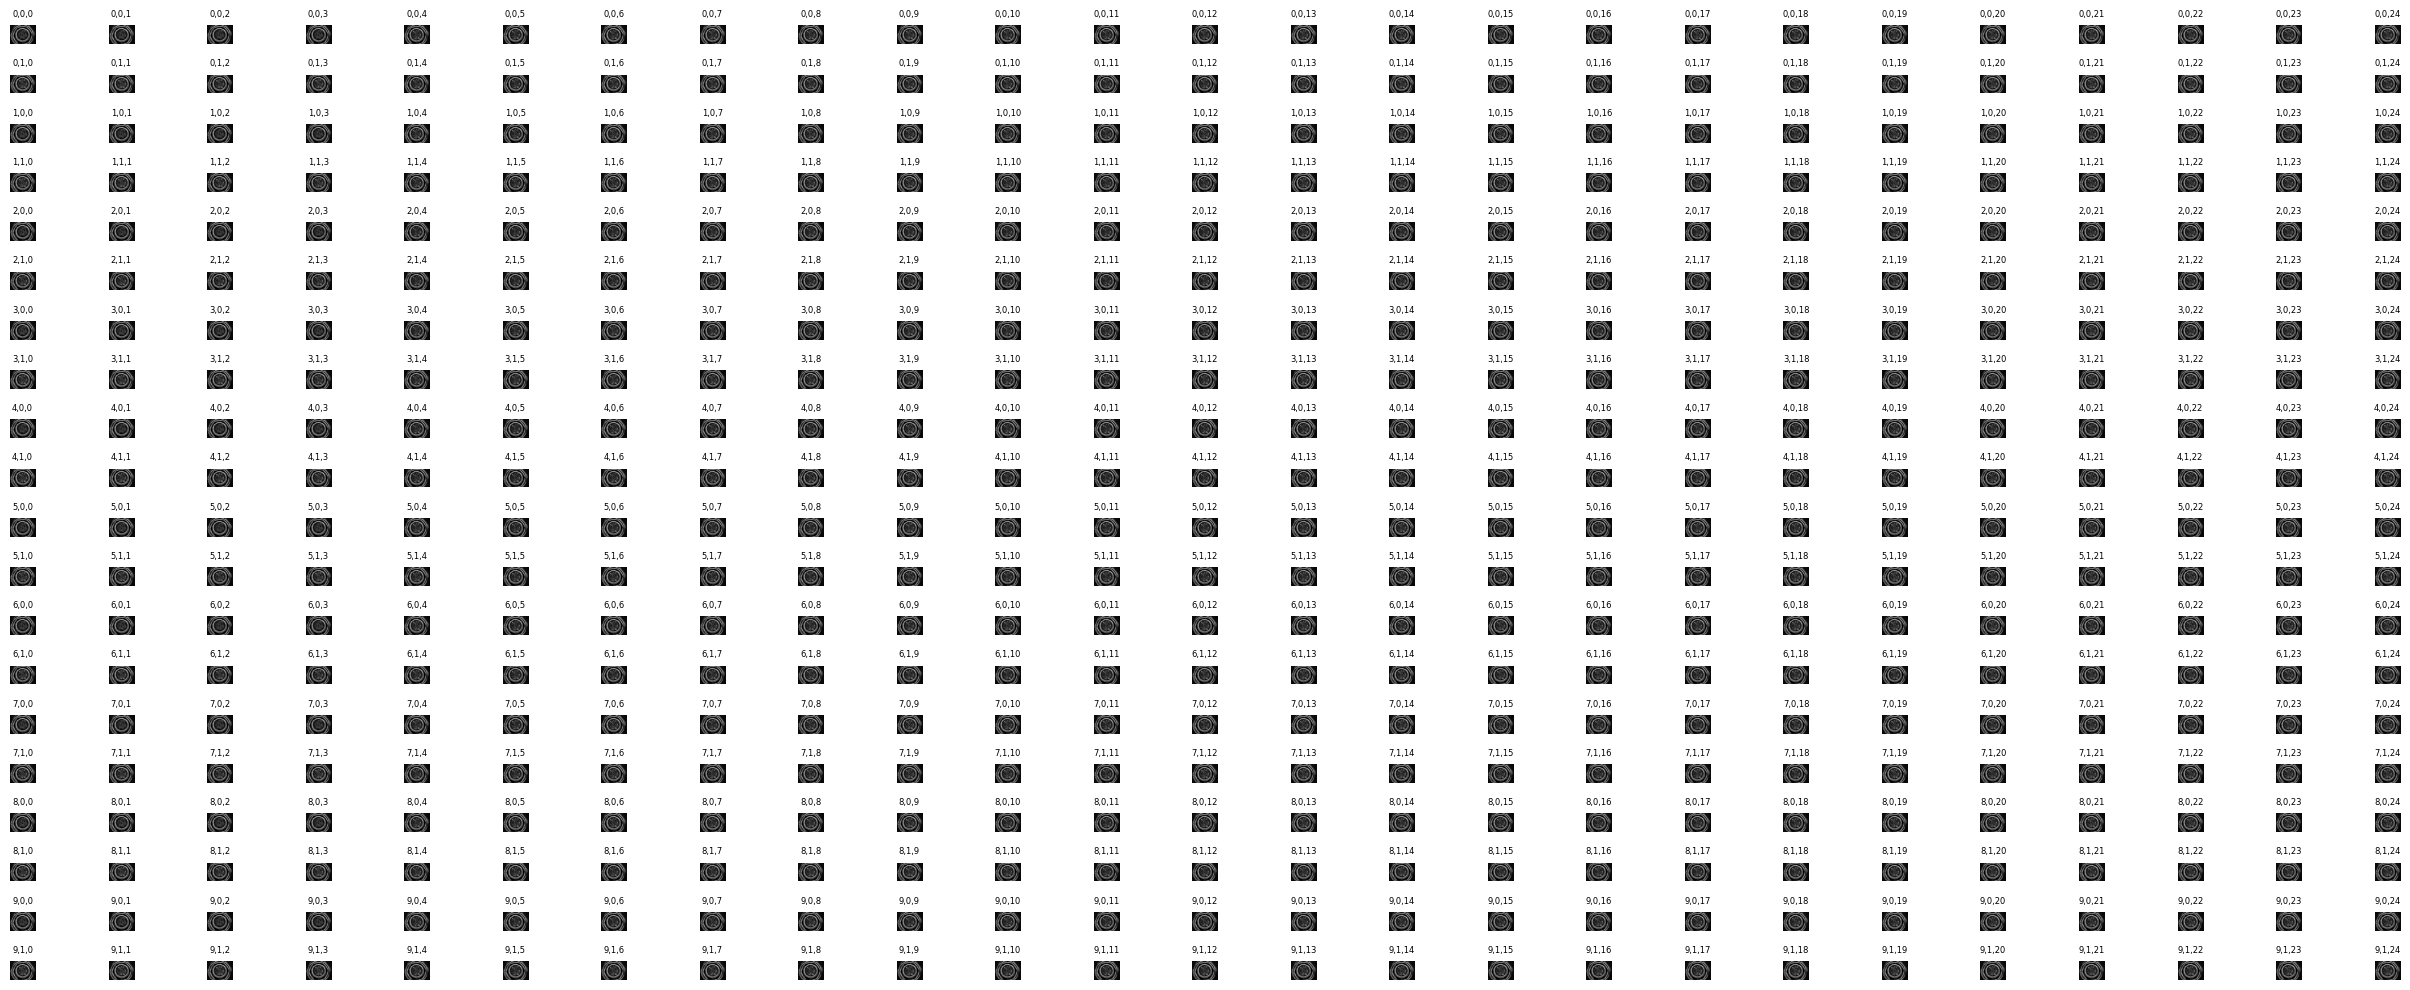

In [ ]:
comb=printers[0]
X_c, y_c = get_data(1
            dataset, X,
            printer=comb[0],
            filament=comb[1],
            pattern=str(2)
        )
print(X_c.shape)
fig, axes = plt.subplots(len(X_c) * 2, 25, figsize=(25, 10))

for i in range(len(X_c)):
    for j in range(2):
        for k in range(25):
            ax = axes[i * 2 + j, k]
            ax.imshow(X_c[i, j, k], cmap="gray")
            ax.axis("off")
            ax.set_title(f"{i},{j},{k}", fontsize=6)

plt.tight_layout()
plt.show()

[[ 300. 1000. 1000. 1000. 1000. 1000.]
 [1000.  500. 1250. 1250. 1250. 1250.]
 [1000. 1250.  500. 1250. 1250. 1250.]
 [1000. 1250. 1250.  500. 1250. 1250.]
 [1000. 1250. 1250. 1250.  500. 1250.]
 [1000. 1250. 1250. 1250. 1250.  500.]]
[[ 750. 1800. 1800. 1800. 1800. 1500.]
 [1800.  750. 1800. 1800. 1800. 1500.]
 [1800. 1800.  750. 1800. 1800. 1500.]
 [1800. 1800. 1800.  750. 1800. 1500.]
 [1800. 1800. 1800. 1800.  750. 1500.]
 [1500. 1500. 1500. 1500. 1500.  500.]]
[[ 750. 1800. 1800. 1800. 1800. 1800.]
 [1800.  750. 1800. 1800. 1800. 1800.]
 [1800. 1800.  750. 1800. 1800. 1800.]
 [1800. 1800. 1800.  750. 1800. 1800.]
 [1800. 1800. 1800. 1800.  750. 1800.]
 [1800. 1800. 1800. 1800. 1800.  750.]]


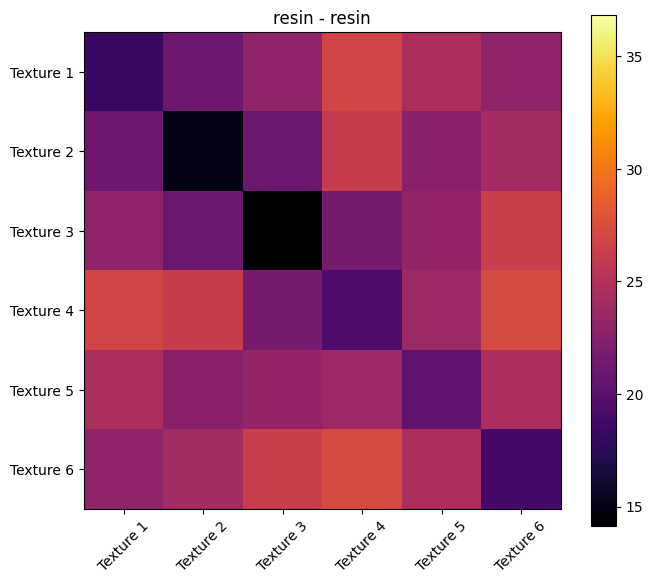

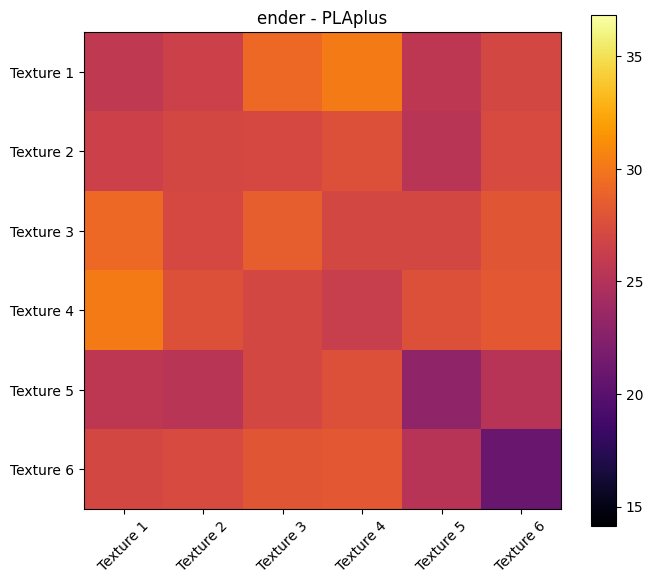

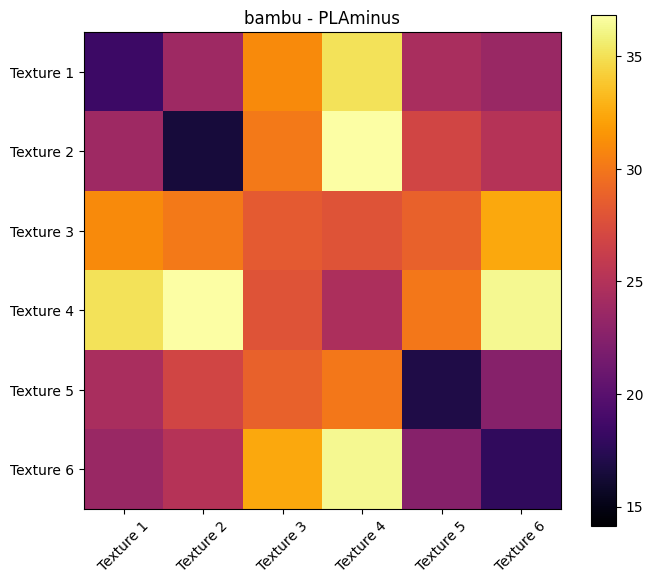

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# Store all grids
grids = []
grids_n = []

for comb in printers:
    printer = comb[0]
    filament = comb[1]

    grid = np.zeros((6, 6))
    grid_n = np.zeros((6, 6))

    for i in range(6):
        X_c, y_c = get_data(
            dataset, X,
            printer=printer,
            filament=filament,
            pattern="z" + str(i),
            pressure="P30"
        )

        for z in range(6):
            ar = []

            X_d, y_d = get_data(
                dataset, X,
                printer=printer,
                filament=filament,
                pattern="z" + str(z),
                pressure="P30"
            )
            if i==z: 
                for j in range(len(X_c)):
                    for k in range(j,len(X_c)):
                        if k!=j:
                                diff = (X_c[k,] - X_c[j,]) ** 2
                                msr_per_point = np.mean(diff, axis=( 2, 3))
                                ar.append(msr_per_point)
                        
            else:
                for j in range(len(X_c)):
                    for k in range(len(X_d)):
                        #if k != j:
                            diff = (X_d[k] - X_c[j]) ** 2
                            msr_per_point = np.mean(diff, axis=( 2, 3))
                            #print(msr_per_point.shape)
                            ar.append(msr_per_point)
            #print(np.array(ar).shape,msr_per_point.shape)
            grid_n[i, z]=len(ar)*25*2
            msr_mean = np.mean(np.array(ar))
            grid[i, z] = msr_mean

    grids.append(grid)
    grids_n.append(grid_n)

    print(grid_n)
# ---------------------------------------------------------
# Use ONE colour scale for all printers
# ---------------------------------------------------------

vmin = min(grid.min() for grid in grids)
vmax = max(grid.max() for grid in grids)

norm = Normalize(vmin=vmin, vmax=vmax)


# ---------------------------------------------------------
# Plot each printer separately
# ---------------------------------------------------------

for comb, grid in zip(printers, grids):

    printer = comb[0]
    filament = comb[1]

    fig, ax = plt.subplots(figsize=(7, 6))

    im = ax.imshow(
        grid,
        cmap="inferno",
        norm=norm
    )


    ax.set_xticks(range(6))
    ax.set_xticklabels(
        ["Texture " + str(i + 1) for i in range(6)],
        rotation=45
    )

    ax.set_yticks(range(6))
    ax.set_yticklabels(
        ["Texture " + str(i + 1) for i in range(6)]
    )

    ax.set_title(f"{printer} - {filament}")

    # Same colour scale for every printer
    fig.colorbar(im, ax=ax)

    fig.tight_layout()

    plt.savefig(
        f"/home/dexter/Documents/GitHub/3D-textures/assets/"
        f"{printer}Mat_.pdf"
    )

    plt.show()

In [ ]:
print(grid_n)

[[1500. 1500. 1500. 1500. 1500. 1500.]
 [1500. 1500. 1500. 1500. 1500. 1500.]
 [1500. 1500. 1500. 1500. 1500. 1500.]
 [1500. 1500. 1500. 1500. 1500. 1500.]
 [1500. 1500. 1500. 1500. 1500. 1500.]
 [1500. 1500. 1500. 1500. 1500. 1500.]]


In [ ]:
printers

[['resin', 'resin'], ['ender', 'PLAplus'], ['bambu', 'PLAminus']]